In [1]:
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt


import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

import warnings
warnings.filterwarnings('ignore')

from halotools.mock_observables import tpcf, return_xyz_formatted_array

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

import psutil
psutil.Process().nice(10)

0.6777 74.71913613009617 74.71913613009617


In [2]:
from typing import List, Tuple, Union

def generate_bins(
    bmin: float,
    bmax: float,
    nbins: int,
    logspaced: bool = True,
    soft: float = 0,
) -> Tuple[np.ndarray, np.ndarray]:
    """Generates equally spaced bins in linear or logarithmic (base 10) space.

    Parameters
    ----------
    bmin : float
        Minimum or lower bound (inclusive)
    bmax : float
        Maximum or upper bound (inclusive)
    nbins : int
        Number of bins to generate
    logspaced : bool, optional
        Generate log-spaced bins, by default True
    soft : float, optional
        If there is softening value, then bmin >= soft, by default 0

    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        Bins and edges in units of bmin and bmax
    """
    if bmin < soft:
        bmin = soft
    # Equally log-spaced bins
    if bmin == 0:
        logspaced = False

    if logspaced:
        r_edges = np.logspace(
            start=np.log10(bmin),
            stop=np.log10(bmax),
            num=nbins + 1,
            base=10,
        )
    else:
        r_edges = np.linspace(
            start=bmin,
            stop=bmax,
            num=nbins + 1,
        )
    # Bin middle point
    rbins = 0.5 * (r_edges[1:] + r_edges[:-1])
    return rbins, r_edges

In [3]:
import psutil
psutil.Process().nice(19)

# define radial bins (may be subject to change later. For now, choosing 20 bins per decade.)
r_cens, r_edges = generate_bins(0.1, 150, 70+1) 

# path to MDPL2 galaxies and for data
gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_gg_150.hdf5'

# sim quantities
L_box = 1_000 # h^-1 Mpc
g_box = L_box // 5 # grid size

with h5.File(gal_path, 'r') as hdf:

    sm_cut = hdf['sm'][()] > 1e10

    gx = hdf['pos'][:, 0][()]
    gy = hdf['pos'][:, 1][()] 
    gz = hdf['pos'][:, 2][()]

    gal_pos = return_xyz_formatted_array(gx, gy, gz, mask=sm_cut)
    
    print('Computing g-g correlation function...')
    xi = tpcf(gal_pos, r_edges, period=L_box, num_threads='max')

    with h5.File(save_path, 'a') as f:
        f.create_dataset(name=f'xi', data=xi, dtype=np.float64)
        f.create_dataset(name=f'r_cens', data=r_cens, dtype=np.float64)
        f.create_dataset(name=f'r_edges', data=r_edges, dtype=np.float64)


Computing g-g correlation function...


In [3]:
# load saved xi
xi_path = '/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_gg_150.hdf5'

hdf = h5.File(xi_path, 'r')

xigg = hdf['xi'][()]
xigg_cov = hdf['xi_cov'][()]

# r_cens = hdf['r_cens'][()] 
# r_edges = hdf['r_edges'][()]

In [5]:
# load reference xi
ref_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_gg_150.hdf5'

r_cens, r_edges = generate_bins(0.1, 150, 70+1) 

hd = h5.File(ref_path, 'r')

xi = hd['xi']


In [12]:
# load ZA xi 
z_path = '/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/zel_LS_150'

zel = np.fromfile(z_path)

rZA = rvals = np.logspace(np.log10(0.1), np.log10(150), 1000)

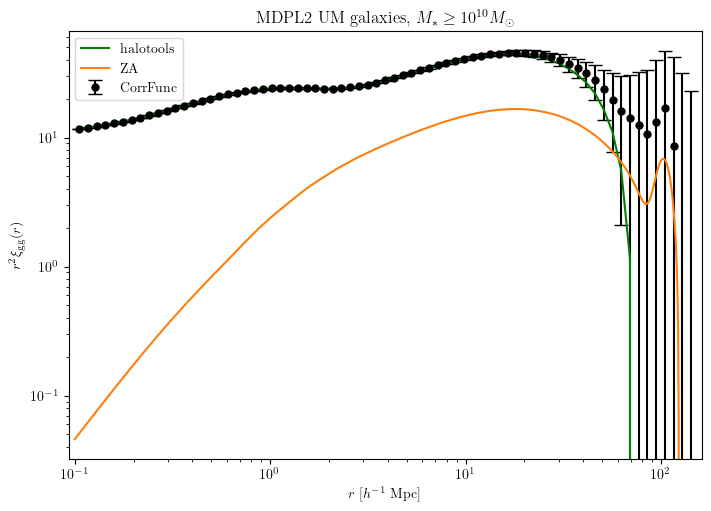

In [14]:
fig, ax = plt.subplots(figsize=(7, 5), layout='constrained')

ax.errorbar(r_cens, r_cens**2*xigg, r_cens**2*np.sqrt(np.diag(xigg_cov)), fmt='o', markersize=5, capsize=5, c='k', label='CorrFunc')
ax.plot(r_cens, r_cens**2*xi, c='g', label='halotools')
ax.plot(rZA, rZA**2*zel, c='C1', label='ZA')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$r\ [h^{-1}$ Mpc]')
ax.set_ylabel(r'$r^2\xi_{\rm gg}(r)$')
ax.set_title(r'MDPL2 UM galaxies, $M_* \geq 10^{10} M_{\odot}$')
ax.margins(x=0.01)
ax.legend()

(-0.1, 0.1)

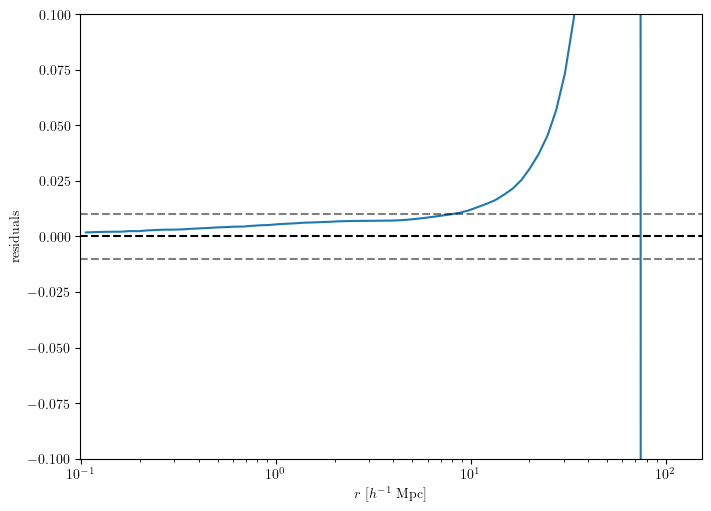

In [10]:
fig, ax = plt.subplots(figsize=(7, 5), layout='constrained')

#ax.errorbar(r_cens, r_cens**2*xigg, r_cens**2*np.sqrt(np.diag(xigg_cov)), fmt='o', markersize=5, capsize=5, c='k', label='CorrFunc')
ax.plot(r_cens, xigg/xi-1)
ax.axhline(0, c='k', ls='--')
ax.axhline(0.01, c='k', ls='--', alpha=0.5)
ax.axhline(-0.01, c='k', ls='--', alpha=0.5)
#ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$r\ [h^{-1}$ Mpc]')
ax.set_ylabel(r'residuals')
#ax.set_title(r'MDPL2 UM galaxies, $M_* \geq 10^{10} M_{\odot}$')
ax.margins(x=0.01)
ax.set_ylim((-0.1, 0.1))

In [ ]:
#check: How does this compare to ZA prediction??